<a href="https://colab.research.google.com/github/IMeme-Supreme/ML-homework/blob/main/jax_jit_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Eager mode**

(5000, 5000)


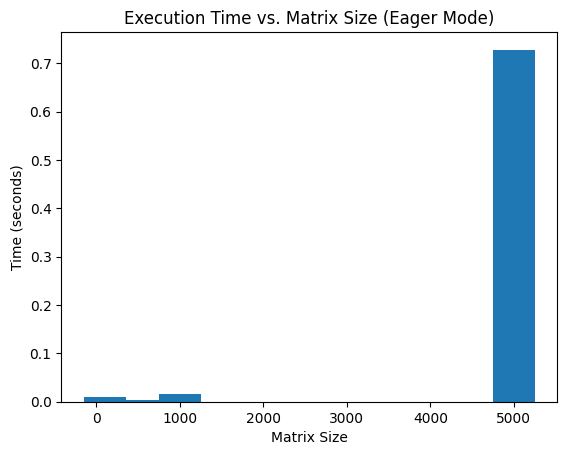

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
import pynvml
from pynvml import *
from torch.profiler import profile, record_function, ProfilerAction
from torch.profiler import profile, record_function, ProfilerActivity
import pandas as pd
import numpy as np
from numba import jit

#create figure
fig, ax = plt.subplots()

tester = [np.random.randn(100, 100), np.random.randn(500, 500), np.random.randn(1000, 1000), np.random.randn(5000, 5000),]
scale = [100, 500, 1000, 5000]
runtimes = list()

def square(a):
  for _ in range(5):
    a = a ** 2
    a = np.log(a)
  return a

for x in range(0, 4):
  start = time.time()
  result = square(tester[x])
  end = time.time()
  runtimes.append(end-start)


ax.bar(scale, runtimes, 500)

ax.set_xlabel('Matrix Size')
ax.set_ylabel('Time (seconds)')
ax.set_title('Execution Time vs. Matrix Size (Eager Mode)')

print(result.shape)

plt.show()


**First call with jit**



(5000, 5000)


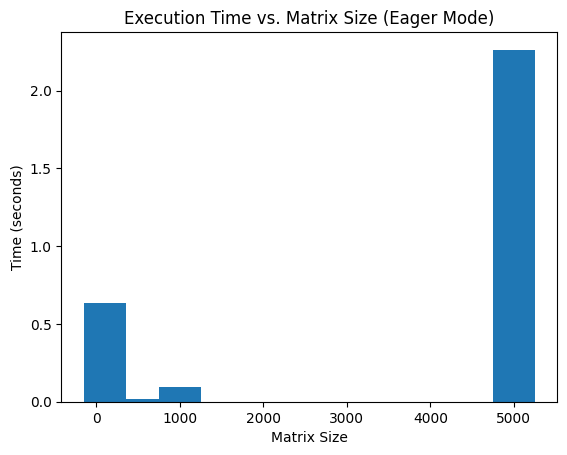

In [ ]:
start = time.time()

fig, ax = plt.subplots()

tester = [np.random.randn(100, 100), np.random.randn(500, 500), np.random.randn(1000, 1000), np.random.randn(5000, 5000),]
scale = [100, 500, 1000, 5000]
runtimes = list()

@jit
def square2(a):
  for _ in range(5):
    a = a ** 2
    a = np.log(a)
  return a

for x in range(0, 4):
  start = time.time()
  result = square2(tester[x])
  end = time.time()
  runtimes.append(end-start)

ax.bar(scale, runtimes,500)

ax.set_xlabel('Matrix Size')
ax.set_ylabel('Time (seconds)')
ax.set_title('Execution Time vs. Matrix Size (Eager Mode)')

print(result.shape)

plt.show()

**Cached compilation**

(5000, 5000)


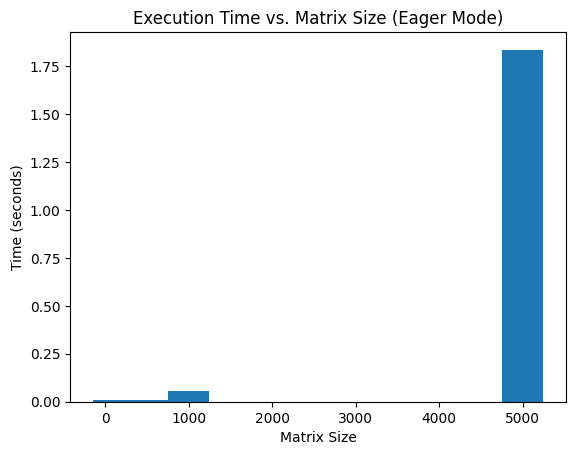

In [ ]:
fig, ax = plt.subplots()

tester = [np.random.randn(100, 100), np.random.randn(500, 500), np.random.randn(1000, 1000), np.random.randn(5000, 5000),]
scale = [100, 500, 1000, 5000]
runtimes = list()

for x in range(0, 4):
  start = time.time()
  result = square2(tester[x])
  end = time.time()
  runtimes.append(end-start)

ax.bar(scale, runtimes, 500)

ax.set_xlabel('Matrix Size')
ax.set_ylabel('Time (seconds)')
ax.set_title('Execution Time vs. Matrix Size (Eager Mode)')

print(result.shape)

plt.show()

the compilation process has a relatively fixed overhead due to numba merging kernels for efficiency. since our overhead difference does not come from compilation, it must be due to the fact that larger matrices require many more steps to perform the operations on. The second graph was a was a weird request to implement considering only the first call can ever show the extra time from compilation.

{ lambda ; a:f32[100,100]. let
    b:f32[] c:f32[] d:f32[] e:f32[] f:f32[] g:f32[] h:f32[] i:f32[] j:f32[] k:f32[]
      l:f32[] m:f32[] n:f32[] o:f32[] p:f32[] q:f32[] r:f32[] s:f32[] t:f32[] u:f32[]
      v:f32[] w:f32[] x:f32[] y:f32[] z:f32[] ba:f32[] bb:f32[] bc:f32[] bd:f32[]
      be:f32[] bf:f32[] bg:f32[] bh:f32[] bi:f32[] bj:f32[] bk:f32[] bl:f32[] bm:f32[]
      bn:f32[] bo:f32[] bp:f32[] bq:f32[] br:f32[] bs:f32[] bt:f32[] bu:f32[] bv:f32[]
      bw:f32[] bx:f32[] by:f32[] bz:f32[] ca:f32[] cb:f32[] cc:f32[] cd:f32[] ce:f32[]
      cf:f32[] cg:f32[] ch:f32[] ci:f32[] cj:f32[] ck:f32[] cl:f32[] cm:f32[] cn:f32[]
      co:f32[] cp:f32[] cq:f32[] cr:f32[] cs:f32[] ct:f32[] cu:f32[] cv:f32[] cw:f32[]
      cx:f32[] cy:f32[] cz:f32[] da:f32[] db:f32[] dc:f32[] dd:f32[] de:f32[] df:f32[]
      dg:f32[] dh:f32[] di:f32[] dj:f32[] dk:f32[] dl:f32[] dm:f32[] dn:f32[] do:f32[]
      dp:f32[] dq:f32[] dr:f32[] ds:f32[] dt:f32[] du:f32[] dv:f32[] dw:f32[] = jit[
      name=rowavg
     

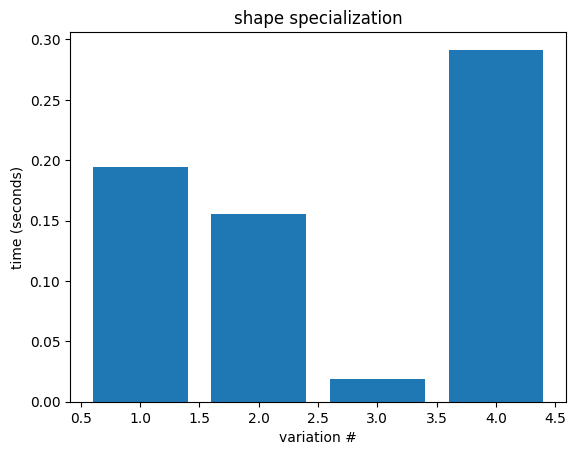

In [ ]:
import jax
import jax.numpy as jnp

key = jax.random.PRNGKey(0)

fig, ax = plt.subplots()

count = [1,2,3,4]

shapes = []

@jax.jit
def rowavg(a):
  averages = []
  rowCount = a.shape[0]
  for i in range(rowCount):
    averages.append(jnp.mean(a[i, :]))

  return averages

shapes = [(100, 100), (100, 200), (100, 100), (200, 100)]
runtimes = list()

for x in range(0, 4):
  start = time.time()
  rand_array = jax.random.uniform(key, shapes[x])
  result = jax.make_jaxpr(rowavg)(rand_array)
  print(result)
  end = time.time()
  runtimes.append(end-start)


ax.bar(count, runtimes)

ax.set_xlabel("variation #")
ax.set_ylabel("time (seconds)")
ax.set_title("shape specialization")

plt.show()


Here we can see that jax retraces when there is a shape it has not encountered (or at least has not recently encountered). for the 3rd run, we see that the runtime is much faster because it does not have to retrace

In [ ]:
myArray = jax.random.uniform(key, shapes[0])


def sin(x):
  x = jnp.sin(x)
  return x

def cos(x):
  x = jnp.cos(x)
  return x

def combo(x):
  sum = 0
  for i in range(0, 100):
    sum += sin(x) + cos(x)
  return sum





In [ ]:
@jax.jit
def allInOne(x):
  sum = 0
  for i in range(0, 100):
    sum += jnp.sin(x) + jnp.cos(x)
  return sum

In [ ]:
myArr = jax.random.uniform(key, (100, 100))

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
    with_stack=True,
) as prof:

  with record_function("Jit version"):
    allInOne(myArr)
print(prof.key_averages().table(sort_by="cuda_time_total"))

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    profile_memory=True,
    record_shapes=True,
    with_stack=True,
) as prof:

    with record_function("Eager execution"):
        combo(myArr) # Changed 'x' to 'myArr'

print(prof.key_averages().table(sort_by="cuda_time_total"))

---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                Jit version        23.51%     425.895us        98.32%       1.781ms       1.781ms           0 B           0 B             1  
    Activity Buffer Request        36.81%     666.809us        36.81%     666.809us     666.809us           0 B           0 B             1  
             cuLaunchKernel        38.00%     688.423us        38.00%     688.423us     688.423us           0 B           0 B             1  
      cudaDeviceSynchronize         1.68%      30.429us         1.68%      30.429us      30.429us           0 B           0 B             1  
------

The jit version has better performance because it only needs to make 1 kernel. We are not doing a lot of work in each individual kernel, therefore the overhead cost of launching many kernels will dramatically increase the time taken in the eager version. since we only have one cuLaunchKernel, all of the operations are fused together into a single kernel. in theory, the jit version will be faster by the exact same amount of time the eager version spent launching it's extra kernels. In practice, it is about 47.776 ms faster (on one particular run)